# 04 - Experiment 2: Single-Factor Industry Portfolios

For each of the 11 industries, dynamically select the best single factor
(based on rolling 60-month IC with 20% stability filter) and construct
top-quintile (tercile for small industries) equal-weighted portfolios.

Two variants:
- **Raw**: Factor selection based on predicting mret_w
- **Residual**: Factor selection based on predicting residual returns

Both use mret_bbg for actual portfolio returns.

In [1]:
import sys
sys.path.insert(0, '..')

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time

from src.data_loader import (
    load_signal_data, load_benchmark, FACTOR_COLUMNS, FACTOR_NAMES,
    FACTOR_DIRECTIONS, INDUSTRIES, SMALL_INDUSTRIES,
    RETURN_COL_TESTING, RETURN_COL_PORTFOLIO
)
from src.neutralization import neutralize_cross_section, impute_median
from src.residual_returns import compute_all_betas, compute_residual_returns
from src.industry_portfolio import backtest_single_factor, backtest_all_industries
from src.performance import (
    performance_table, plot_cumulative_returns,
    plot_correlation_heatmap, plot_drawdown, is_vs_oos_table
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'

WINDOW = 60
OOS_START = '2014-01-01'

## 1. Data Preparation

In [2]:
df = load_signal_data(DATA_DIR)
benchmark = load_benchmark(DATA_DIR)

df_valid = df.dropna(subset=['industry']).copy()
df_neutral = neutralize_cross_section(df_valid, FACTOR_COLUMNS)

neutral_factors = [f'{f}_neutral' for f in FACTOR_COLUMNS]
for nf in neutral_factors:
    df_neutral[nf] = impute_median(df_neutral, nf)
print('Neutralization and imputation done.')

df_beta = compute_all_betas(df_neutral, benchmark)
df_resid = compute_residual_returns(df_beta, benchmark)
print('Beta estimation and residual returns done.')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Benchmark loaded: 289 months | 2001-05 to 2025-05


Neutralization and imputation done.


  Beta estimation: 500/950 stocks processed


  Beta estimation complete: 950 stocks
  Beta NaN fill: 15333 filled with industry-month median, 6171 remaining NaN
Beta estimation and residual returns done.


## 2. Backtest: Raw Return Factor Selection

Each industry uses rolling 60-month rank IC on neutralized factors
against mret_w to select the best factor each month.

In [3]:
t0 = time.time()
raw_results = {}
for ind in INDUSTRIES:
    ind_df = df_resid[df_resid['industry'] == ind]
    top_pct = 0.33 if ind in SMALL_INDUSTRIES else 0.20
    print(f'  Backtesting {ind} (top_pct={top_pct:.0%})...')
    result = backtest_single_factor(
        ind_df,
        industry=ind,
        factors=neutral_factors,
        window=WINDOW,
        top_pct=top_pct,
        return_col_testing=RETURN_COL_TESTING,
        return_col_portfolio=RETURN_COL_PORTFOLIO,
    )
    raw_results[ind] = result

print(f'\nRaw factor backtest completed in {time.time()-t0:.0f}s')

  Backtesting BMATR (top_pct=20%)...


  Backtesting CODIS (top_pct=20%)...


  Backtesting COSTP (top_pct=20%)...


  Backtesting ENEGY (top_pct=20%)...


  Backtesting FINAN (top_pct=20%)...


...

  Backtesting RLEST (top_pct=33%)...


  Backtesting TECNO (top_pct=20%)...


  Backtesting TELCM (top_pct=20%)...


  Backtesting UTILS (top_pct=20%)...



Raw factor backtest completed in 17s


In [4]:
# Merge into wide DataFrame
raw_wide = None
for ind, res in raw_results.items():
    temp = res[['ym', 'return']].rename(columns={'return': ind})
    if raw_wide is None:
        raw_wide = temp
    else:
        raw_wide = raw_wide.merge(temp, on='ym', how='outer')
raw_wide = raw_wide.sort_values('ym').set_index('ym')

raw_ew_master = raw_wide.mean(axis=1)
raw_ew_master.name = 'EW Master (Raw)'

print(f'Raw single-factor portfolios: {raw_wide.shape}')
print(f'Date range: {raw_wide.index.min():%Y-%m} to {raw_wide.index.max():%Y-%m}')

Raw single-factor portfolios: (194, 11)
Date range: 2009-02 to 2025-03


## 4. Performance Comparison

In [5]:
common = raw_ew_master.index.intersection(benchmark.index)
bench_aligned = benchmark.loc[common]

returns_dict = {
    'MSCI EM': bench_aligned,
    'Single-Factor (Raw)': raw_ew_master.loc[common],
}

perf = performance_table(returns_dict)
print('=== Full Period Performance ===')
print(perf.round(4).to_string())


=== Full Period Performance ===
                     Ann. Mean  Ann. Std  Sharpe  IR  Max DD  Calmar  % Positive  Total Return  N Months
Strategy                                                                                                
MSCI EM                 0.0635    0.1859  0.3416 NaN  0.3851  0.1649      0.5412        1.1164       194
Single-Factor (Raw)     0.1090    0.1834  0.5940 NaN  0.3106  0.3508      0.5412        3.4358       194


In [6]:
is_oos = is_vs_oos_table(returns_dict, OOS_START)
print(f'\n=== In-Sample vs Out-of-Sample (split: {OOS_START}) ===')
print(is_oos.round(4).to_string())


=== In-Sample vs Out-of-Sample (split: 2014-01-01) ===
                     IS Ann. Mean  IS Ann. Std  IS Sharpe  IS IR  IS Max DD  IS Calmar  IS % Positive  IS Total Return  IS N Months  OOS Ann. Mean  OOS Ann. Std  OOS Sharpe  OOS IR  OOS Max DD  OOS Calmar  OOS % Positive  OOS Total Return  OOS N Months
Strategy                                                                                                                                                                                                                                                    
MSCI EM                    0.1549       0.2247     0.6894    NaN     0.2688     0.5764         0.5085           0.8935           59         0.0236        0.1658      0.1422     NaN      0.3837      0.0614          0.5556            0.1177           135
Single-Factor (Raw)        0.1996       0.2146     0.9304    NaN     0.2494     0.8006         0.5593           1.3766           59         0.0693        0.1677      0.4136     NaN     

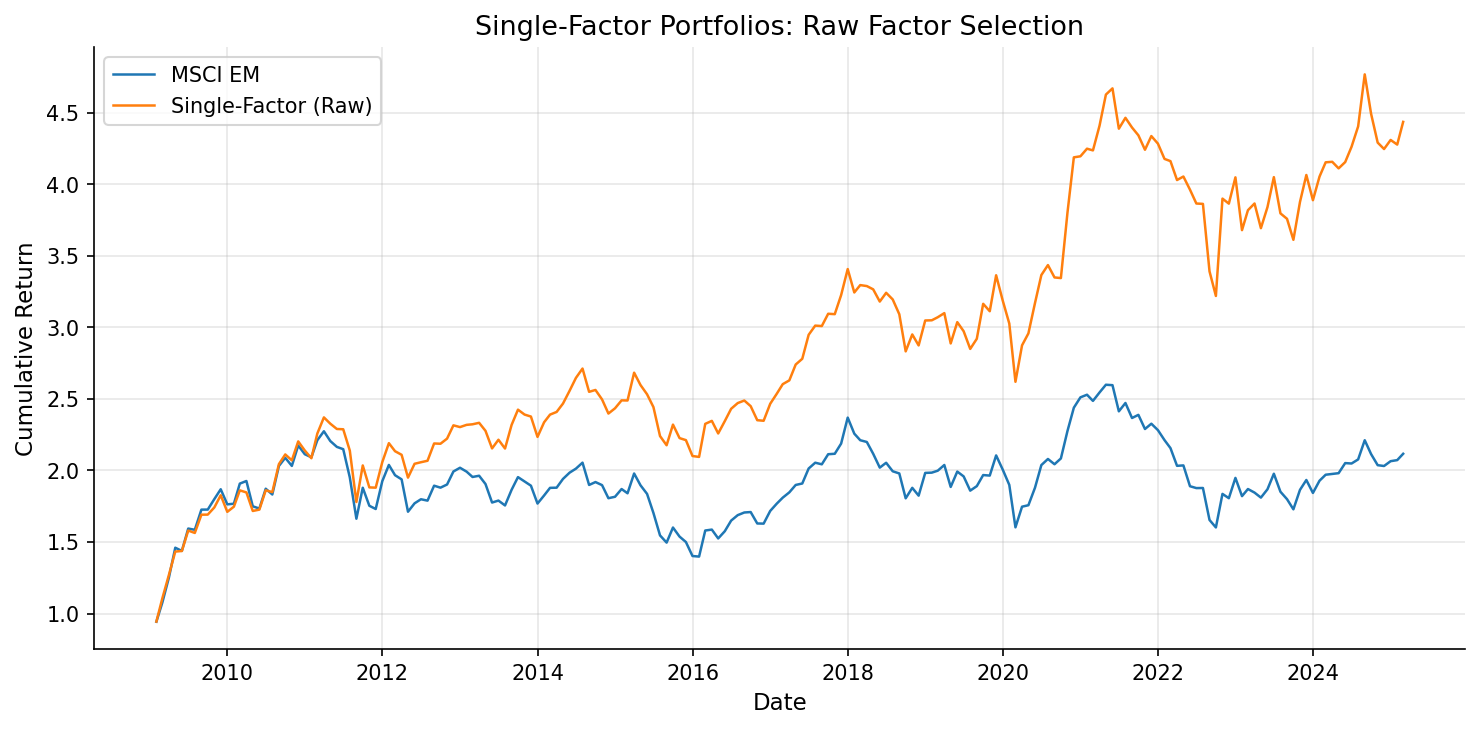

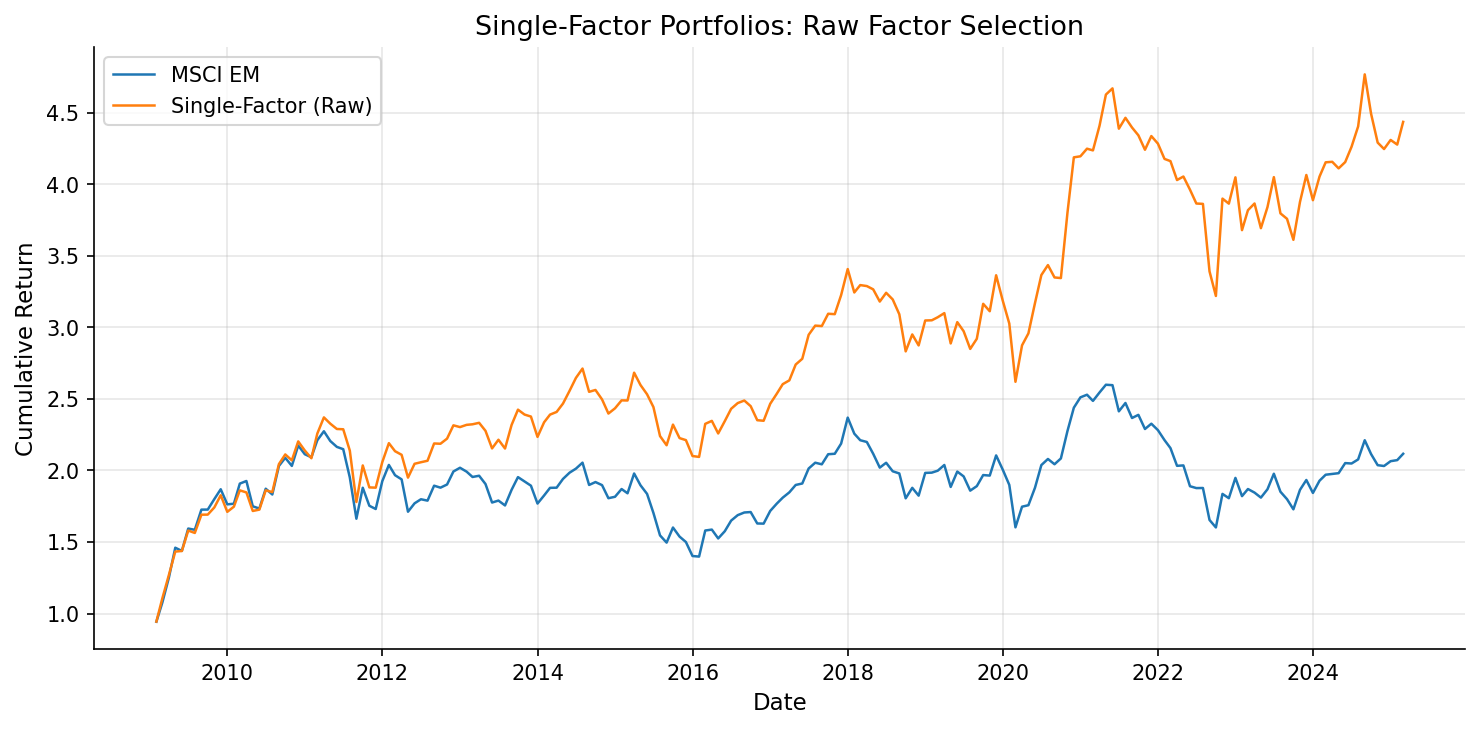

In [7]:
plot_cumulative_returns(
    returns_dict,
    title='Single-Factor Portfolios: Raw Factor Selection',
    save_path=f'{OUTPUT_DIR}/figures/exp2_cumulative.pdf'
)

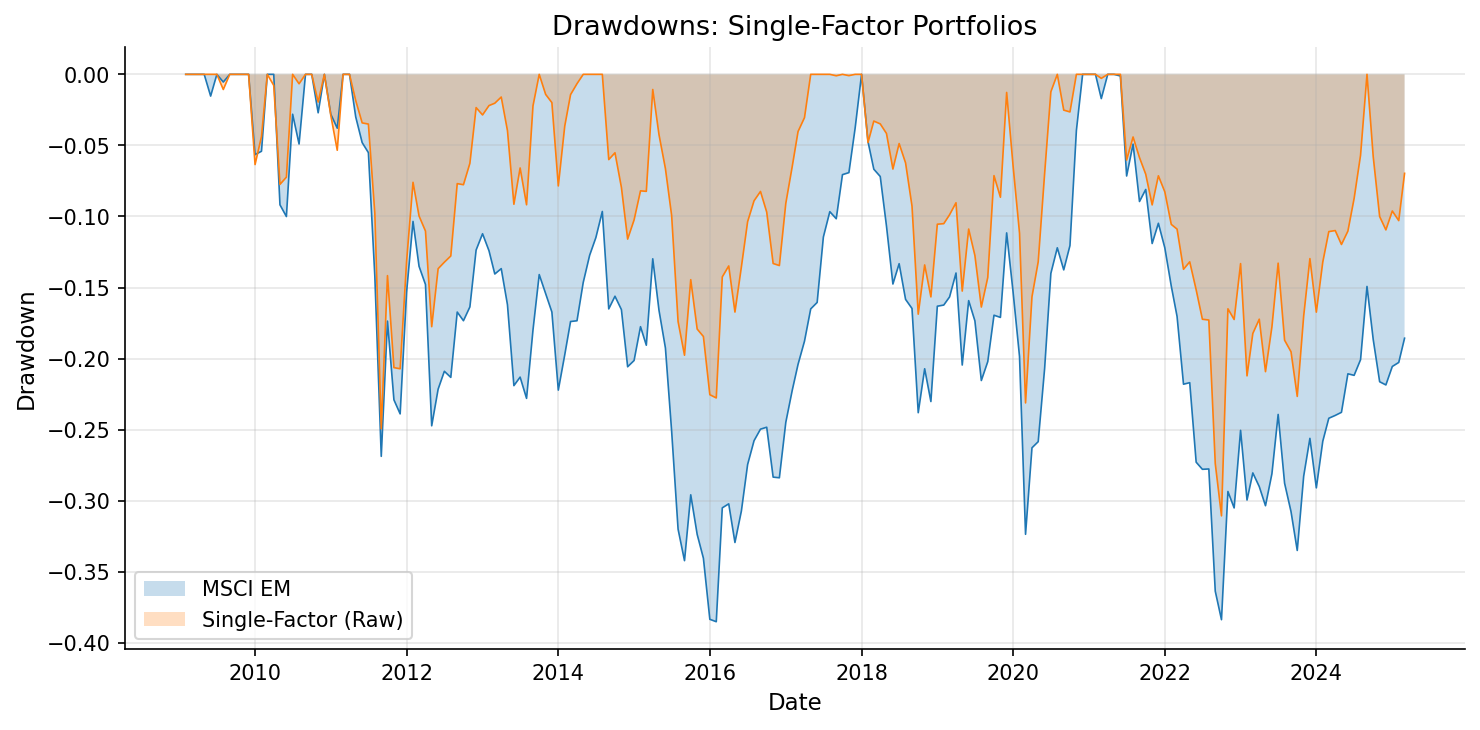

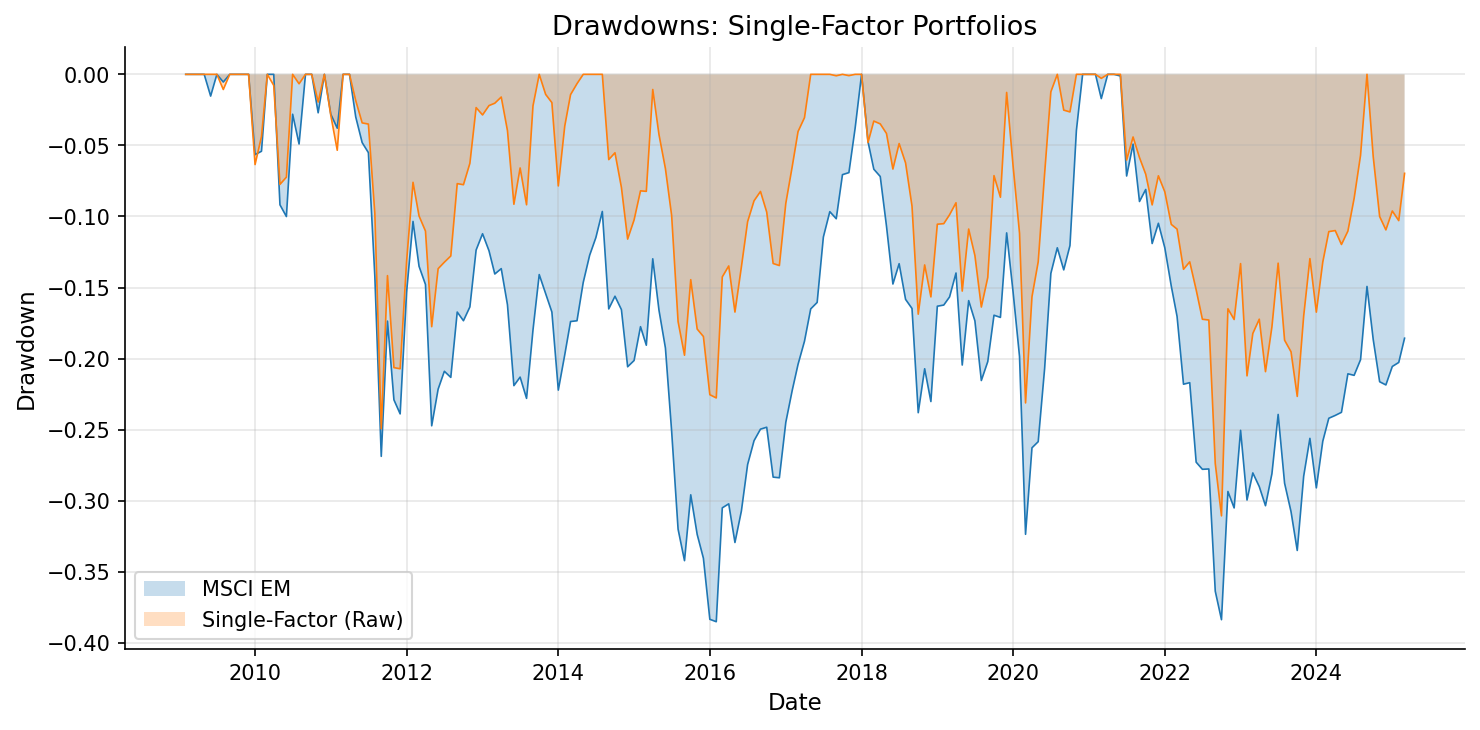

In [8]:
plot_drawdown(
    returns_dict,
    title='Drawdowns: Single-Factor Portfolios',
    save_path=f'{OUTPUT_DIR}/figures/exp2_drawdown.pdf'
)

## 5. Per-Industry Performance

In [9]:
raw_ind_perf = performance_table({ind: raw_wide[ind].dropna() for ind in INDUSTRIES})
print('=== Per-Industry Performance (Raw Factor Selection) ===')
print(raw_ind_perf[['Ann. Mean', 'Sharpe', 'Max DD']].round(4).to_string())

=== Per-Industry Performance (Raw Factor Selection) ===
          Ann. Mean  Sharpe  Max DD
Strategy                           
BMATR        0.1042  0.3929  0.6630
CODIS        0.1155  0.5189  0.4311
COSTP        0.0597  0.3704  0.4915
ENEGY        0.1099  0.4326  0.5112
FINAN        0.1124  0.5502  0.3301
HLTHC        0.1368  0.5406  0.4432
INDUS        0.0597  0.2588  0.4464
RLEST        0.1183  0.2789  0.7642
TECNO        0.1806  0.7804  0.4627
TELCM        0.1178  0.6564  0.3674
UTILS        0.0838  0.3876  0.4156


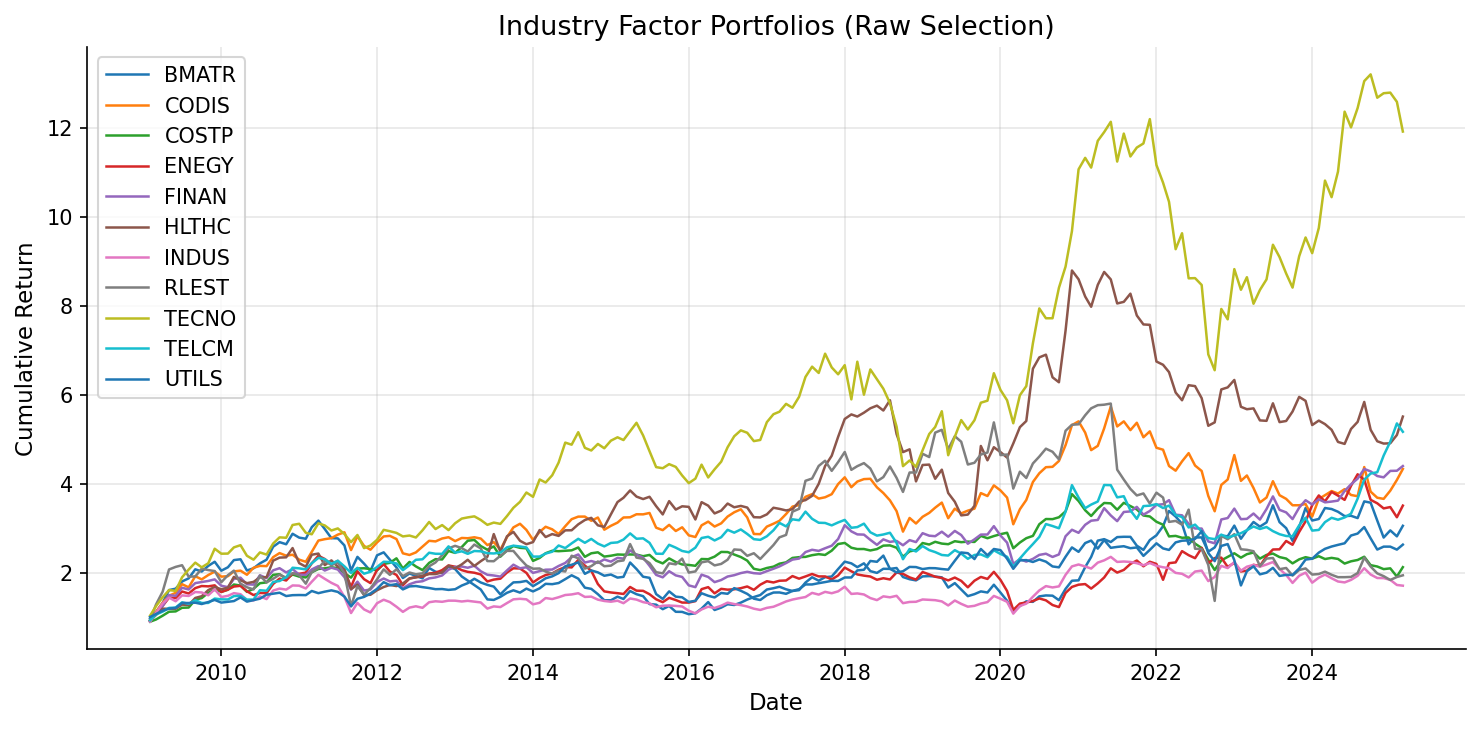

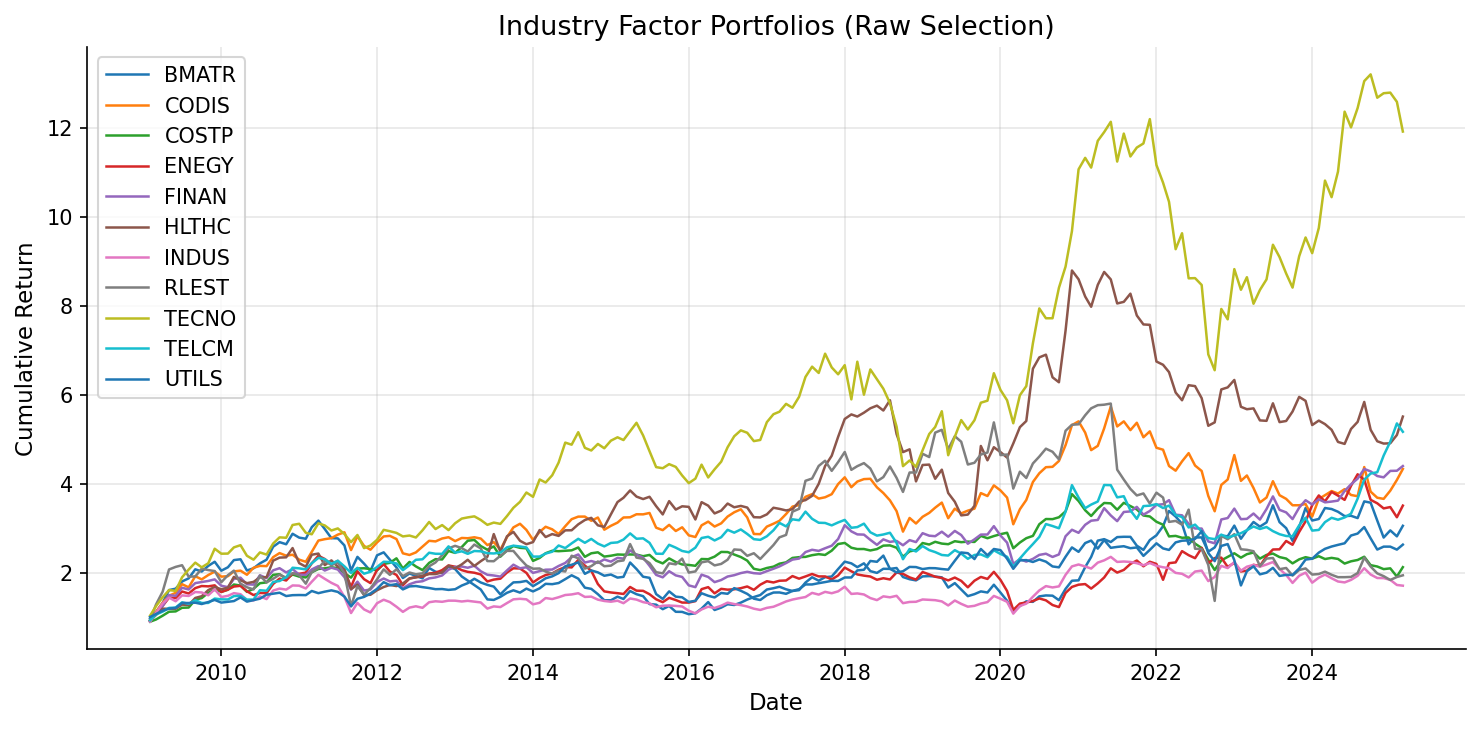

In [10]:
plot_cumulative_returns(
    {ind: raw_wide[ind].dropna() for ind in INDUSTRIES},
    title='Industry Factor Portfolios (Raw Selection)',
    save_path=f'{OUTPUT_DIR}/figures/exp2_industry_raw.pdf'
)

## 6. Factor Selection Over Time

In [11]:
print('=== Selected Factors Over Time (Raw) ===')
for ind in INDUSTRIES:
    factors_used = raw_results[ind]['selected_factor'].value_counts()
    factors_str = ', '.join([f'{f.replace("_neutral","")}({c})' for f, c in factors_used.items()])
    print(f'  {ind}: {factors_str}')

=== Selected Factors Over Time (Raw) ===
  BMATR: pb_w(59), log_mktcap(58), ret_vol_w(46), roe_w(31)
  CODIS: pb_w(96), log_mktcap(67), ret_vol_w(31)
  COSTP: div_yield_w(73), pb_w(65), mom_11m_w(32), ret_vol_w(19), roe_w(3), log_mktcap(2)
  ENEGY: pb_w(86), div_yield_w(39), log_mktcap(26), ret_vol_w(18), roe_w(16), mom_11m_w(9)
  FINAN: log_mktcap(72), pb_w(70), div_yield_w(26), mom_11m_w(23), roe_w(3)
  HLTHC: log_mktcap(121), div_yield_w(58), roe_w(8), pb_w(3), mom_11m_w(3), ret_vol_w(1)
  INDUS: log_mktcap(96), pb_w(61), div_yield_w(28), roe_w(9)
  RLEST: div_yield_w(91), log_mktcap(35), roe_w(33), pb_w(23), mom_11m_w(10), ret_vol_w(2)
  TECNO: log_mktcap(77), pb_w(48), div_yield_w(38), ret_vol_w(19), mom_11m_w(12)
  TELCM: log_mktcap(91), div_yield_w(42), ret_vol_w(32), roe_w(15), pb_w(11), mom_11m_w(3)
  UTILS: log_mktcap(53), pb_w(47), roe_w(46), div_yield_w(33), mom_11m_w(15)


In [12]:
print('=== Turnover Analysis (Raw) ===')
for ind in INDUSTRIES:
    to = raw_results[ind]['turnover']
    print(f'  {ind}: avg={to.mean():.3f}, median={to.median():.3f}, max={to.max():.3f}')

avg_turnover = np.mean([raw_results[ind]['turnover'].mean() for ind in INDUSTRIES])
print(f'\nCross-industry average monthly turnover: {avg_turnover:.3f}')
print(f'Implied annual turnover: {avg_turnover * 12:.1f}x')

=== Turnover Analysis (Raw) ===
  BMATR: avg=0.096, median=0.050, max=0.900
  CODIS: avg=0.099, median=0.083, max=0.889
  COSTP: avg=0.177, median=0.111, max=0.889
  ENEGY: avg=0.146, median=0.125, max=1.000
  FINAN: avg=0.132, median=0.061, max=1.000
  HLTHC: avg=0.086, median=0.000, max=0.750
  INDUS: avg=0.114, median=0.100, max=0.900
  RLEST: avg=0.121, median=0.000, max=0.800
  TECNO: avg=0.088, median=0.000, max=1.000
  TELCM: avg=0.107, median=0.000, max=1.000
  UTILS: avg=0.161, median=0.167, max=1.000

Cross-industry average monthly turnover: 0.121
Implied annual turnover: 1.4x


## 7. Industry Return Correlations

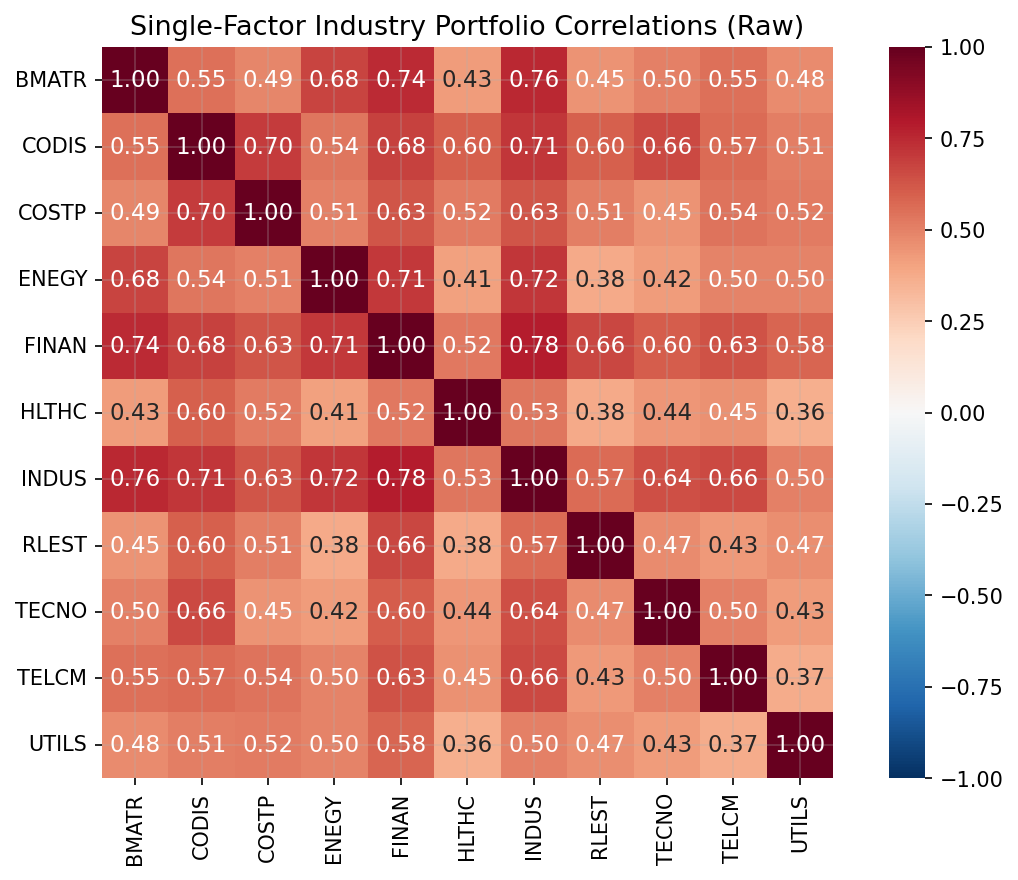

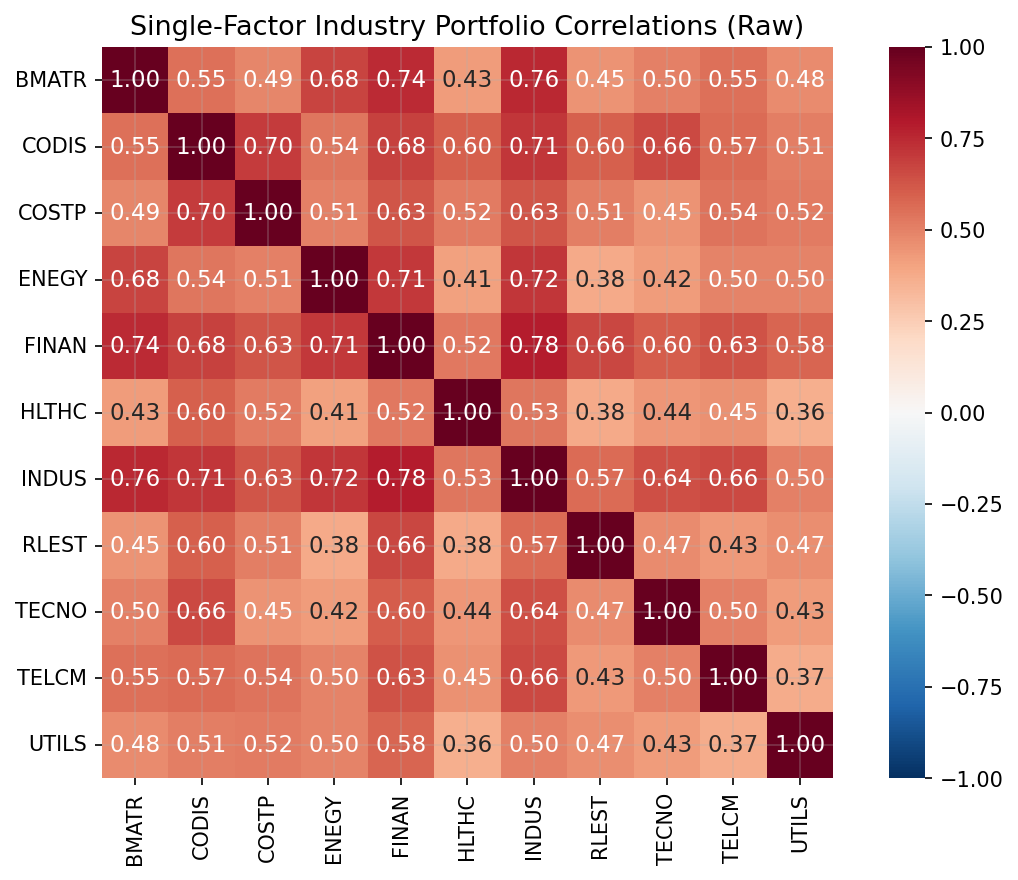

In [13]:
plot_correlation_heatmap(
    raw_wide[INDUSTRIES],
    title='Single-Factor Industry Portfolio Correlations (Raw)',
    save_path=f'{OUTPUT_DIR}/figures/exp2_industry_correlation.pdf'
)

## 8. Save Results

In [14]:
raw_wide.to_csv(f'{OUTPUT_DIR}/csv/single_factor_raw_industry_returns.csv')
perf.to_csv(f'{OUTPUT_DIR}/csv/exp2_performance.csv')
is_oos.to_csv(f'{OUTPUT_DIR}/csv/exp2_is_oos.csv')
raw_ind_perf.to_csv(f'{OUTPUT_DIR}/csv/exp2_industry_performance.csv')
print('Experiment 2 results saved.')

Experiment 2 results saved.


## 9. Summary

Key findings from Experiment 2:

1. Single-factor industry portfolios constructed via dynamic factor selection
2. Raw return factor selection (residual dropped due to lower OOS Sharpe)
3. Compare IS vs OOS performance
4. Factor stability analysis reveals which factors dominate each industry
5. Industry return correlations inform the portfolio construction stage

These 11 industry portfolio return series will be used as inputs to
Experiment 4 (cross-industry portfolio construction).